In [28]:
import matplotlib.pyplot as plt
import matplotlib
from functools import partial
import numpy as np
import pickle
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.cm as cm

import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
from shapely.geometry import LineString  # purely geometric intersection

'''
col = (3.5,3.5)
col_margins = {'top':0.98,'right':0.98,'left':.2,'bottom':.15}
wide = (7.5,3.5)
wide_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.15}
full = (7.5,6)
full_margins = {'top':0.98,'right':0.98,'left':.1,'bottom':.1}
'''

matplotlib.rcParams.update({'font.size': 11})
matplotlib.rcParams.update({'axes.grid':True})
matplotlib.rcParams.update({'xtick.direction':'in'})
matplotlib.rcParams.update({'ytick.direction':'in'})
matplotlib.rcParams.update({'xtick.top':True})
matplotlib.rcParams.update({'ytick.right':True})
matplotlib.rcParams.update({'legend.fontsize':'small'})
matplotlib.rcParams.update({'legend.frameon':False})
matplotlib.rcParams.update({'legend.fancybox':False})
matplotlib.rcParams.update({'legend.framealpha':0.6})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
matplotlib.rcParams.update({'lines.dashed_pattern':[7,3]})
RAM_MB = 8 *1024
x = np.arange(1,64*2)
y = np.arange(1,30)
T_grid, N_grid = np.meshgrid(x, y)

Coadded maps


In [29]:
file_perfs = 'fits_and_hdf5/namap_perf_profiling_coadded_maps.p'
perfs = pickle.load( open(file_perfs, 'rb'))

[0.037147, 0.037938, 0.038601, 0.039458, 0.040145, 0.04089, 0.041559, 0.04221, 0.042784, 0.044567, 0.04613]
[0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472, 0.05472]


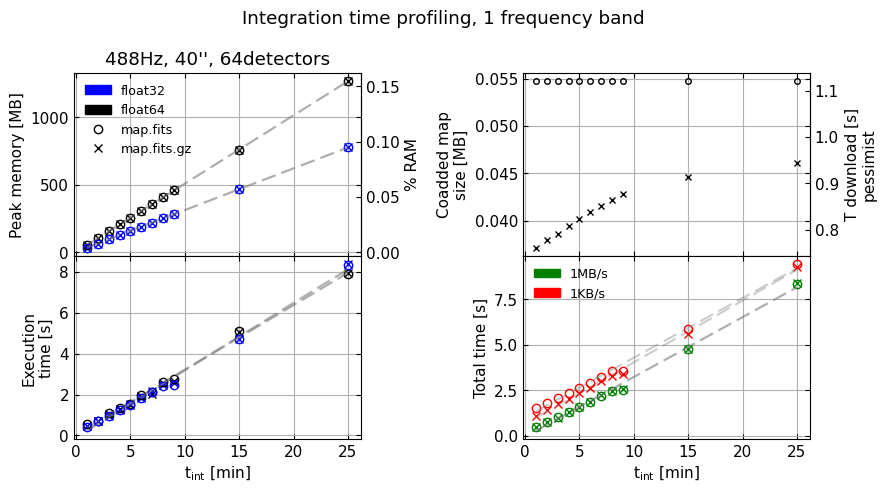

In [30]:

fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True)#,gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle("Integration time profiling, 1 frequency band")
axm, axb, axt, axT = axs[0,0], axs[0,1], axs[1,0], axs[1,1], 
key = 'profiling vs tod time'
key2 = "t_int"

for map_compression, marker in zip(('coadd.fits.gz', 'coadd.fits'), ('x','o')):
    axb.plot(perfs[key][key2], perfs[key]['float64'][map_compression]['output size [MB]'], marker,mfc='none',mec='k', markersize=4)
    print(perfs[key]['float64'][map_compression]['output size [MB]'])

    for precision, color in zip(('float64', 'float32'),('k','b','r')): 
        axm.plot(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

        axt.plot(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'],f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, colort, label in zip((0.048828125, 1), ('r','g'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key]['float32'][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key]['float32'][map_compression]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,f'{marker}', mfc='none',mec=colort, label=label)


        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
patch = mlines.Line2D([], [], linestyle='None',marker='o',    markerfacecolor='none',  markeredgecolor='k',  label='map.fits'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='map.fits.gz'); patchs.append(patch)
axm.legend(handles=patchs)

patchs = []
patch = mpatches.Patch(color='g', label='1MB/s'); patchs.append(patch); 
patch = mpatches.Patch(color='r', label='1KB/s'); patchs.append(patch); 
axT.legend(handles=patchs)


def f_to_z(x): return x/ (8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axT.set_ylabel('Total time [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axT.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

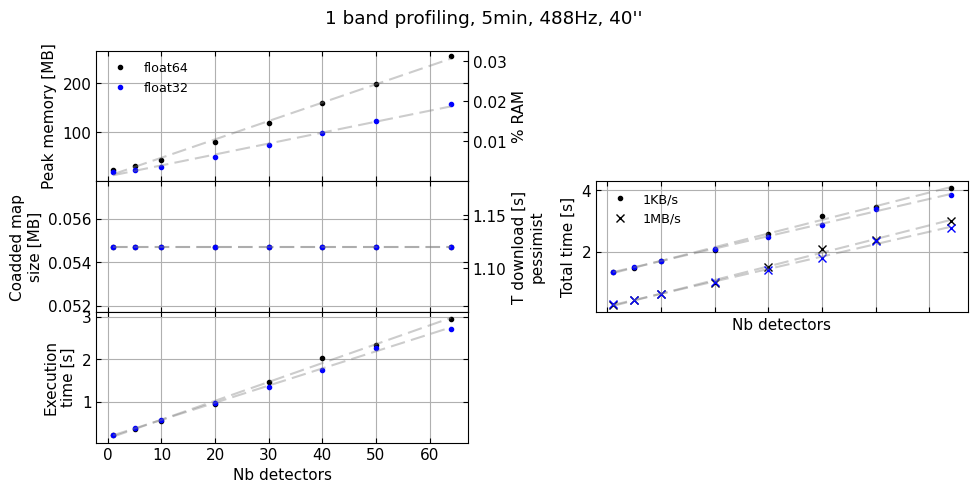

In [31]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[1,1]
axs[2,1].axis('off')
axs[0,1].axis('off')
key = 'profiling vs nb of detectors'
key2 = "nb detectors"

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
    
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')


    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
    

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        
        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)

patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
axT.legend(handles=patchs)

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("1 band profiling, 5min, 488Hz, 40''")
axt.set_xlabel("Nb detectors")
axb.set_ylabel('Coadded map\nsize [MB]')
axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb detectors")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

ValueError: x and y must have same first dimension, but have shapes (9,) and (88,)

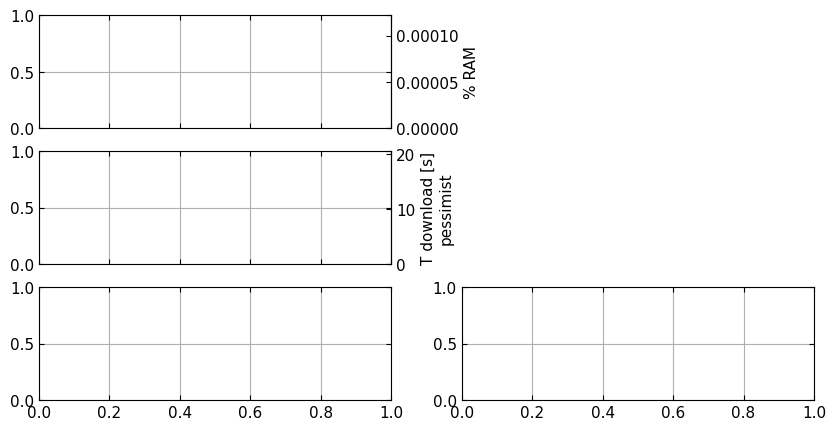

In [32]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[2,1]
axs[1,1].axis('off')
axs[0,1].axis('off')

key = 'profiling vs nb bands'
key2 = "nb bands"

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

for precision, color in zip(('float64', 'float32'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
        axT.vlines(16, 0, Ttot.max(), color='r')


patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)

patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='r', linestyle='solid',label='1 sub-array'); patchs.append(patch)

axT.legend(handles=patchs, loc= 'lower right')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("profiling vs nb of bands\n5min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axT.set_xlabel("Nb bands")

axb.set_ylabel('Coadded map\nsize [MB]')

axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb bands")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

/tmp/ipykernel_55097/3154907939.py:36: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',


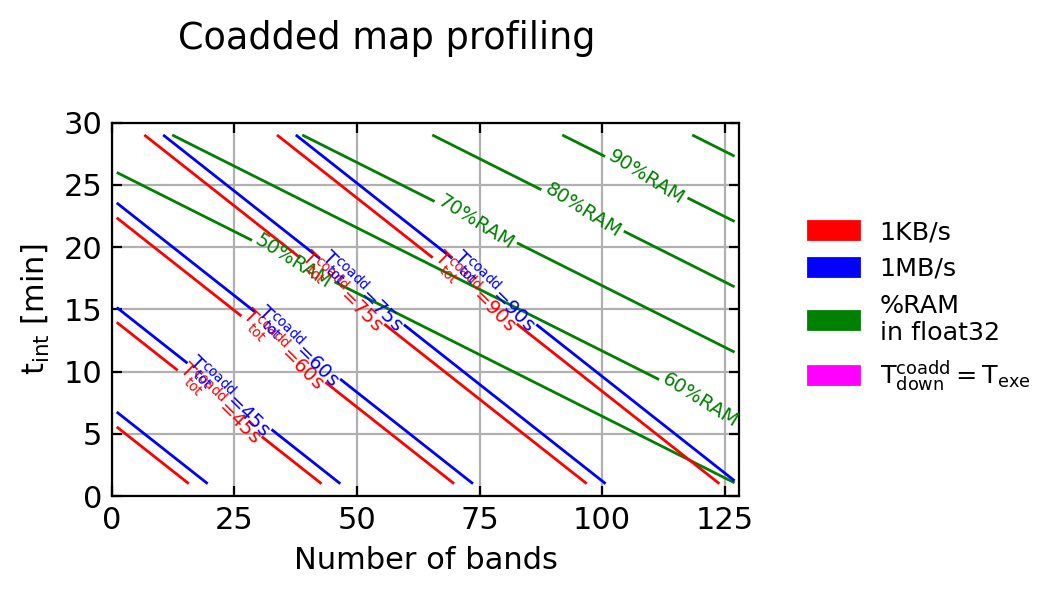

In [6]:


patchs = []
fig, ax = plt.subplots(figsize=(8/2,6/2), dpi=200)
ax.set_xlim(0,64*2)
ax.set_xlabel('Number of bands')
ax.set_ylim(0,30)
ax.set_ylabel('$\\rm t_{int}$ [min]')


#------------------------------
key = 'profiling vs nb bands'
key2 = "nb bands"
precision='float32'
peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_band, b_band = coeffs
#------------------------------

#------------------------------
key = 'profiling vs tod time'
key2 = "t_int"
map_compression = 'coadd.fits'
peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_tint, b_tint = coeffs
#------------------------------

peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)
'''
im = ax.imshow(peak_mem_tot, cmap='binary')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Peak Memory [%]')
'''
levels = (0.5,0.6,0.7, 0.8, 0.9, 1)  # 6 contour levels
CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',
                extent=[x.min(), x.max(), y.min(), y.max()])
ax.clabel(CS, inline=True, fmt=lambda v: f"{v*100:.0f}%RAM", fontsize=7, colors='g')


for telemetry, colort, label in zip((0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):

    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_band, b_band = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'coadd.fits'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_tint, b_tint = coeffs

    Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
    
    '''
    im = ax.imshow(Ttot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('$\\rm T_{tot}$ [min]')
    '''
    # --- Add constant Ttot lines
    levels = np.asarray((15,30,45,60,75,90))/60  # 6 contour levels
    CS = ax.contour(Ttot, levels=levels, colors=colort, linewidths=1.0,
                    extent=[x.min(), x.max(), y.min(), y.max()])
    ax.clabel(CS, inline=True, fmt=lambda v: "$\\rm T^{coadd}_{tot}$="+f"{v*60:.0f}s", fontsize=7, colors=colort)
    patch = mpatches.Patch(color=colort, label=label); patchs.append(patch); 
    #------------------------------

    #------------------------------
    
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    coeffs = np.polyfit(perfs[key][key2], telemetry_time, 1)
    a_band_telemetry, b_band_telemetry = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'coadd.fits'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    coeffs = np.polyfit(perfs[key][key2], telemetry_time, 1)
    a_tint_telemetry, b_tint_telemetry = coeffs

    #------------------------------
    
    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb bands"
    precision='float32'

    execution_time = np.asarray(perfs[key][precision]['time [s]'])
    coeffs = np.polyfit(perfs[key][key2], execution_time, 1)
    a_band_execution, b_band_execution = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'coadd.fits'
    execution_time =  np.asarray(perfs[key][precision][map_compression]['time [s]'])
    coeffs = np.polyfit(perfs[key][key2], execution_time, 1)
    a_tint_execution, b_tint_execution = coeffs

    # Compute y where execution_time_tot = telemetry_time_tot
    delta_a_tint = a_tint_execution - a_tint_telemetry
    delta_a_band = a_band_execution - a_band_telemetry
    delta_b_tint = b_tint_execution - b_tint_telemetry
    delta_b_band = b_band_execution - b_band_telemetry

    y_boundary = -(delta_a_band * x + delta_b_tint + delta_b_band) / delta_a_tint
    ax.plot(x, y_boundary, 'magenta',  label='execution = telemetry')   
    #------------------------------
    
fig.suptitle('Coadded map profiling')

fig.tight_layout()
patch = mpatches.Patch(color='g', label='%RAM\nin float32'); patchs.append(patch); 
patch = mpatches.Patch(color='magenta', label='$\\rm T^{coadd}_{down}=T_{exe}$'); patchs.append(patch); 

ax.legend(handles=patchs, bbox_to_anchor = (1.5,0.8))


In [2]:
file_perfs = 'fits_and_hdf5/namap_perf_profiling_individual_maps.p'
perfs = pickle.load( open(file_perfs, 'rb'))

[0.11279296875, 0.11376094818115234, 0.11448955535888672, 0.11540031433105469, 0.1160430908203125, 0.11679935455322266, 0.1174917221069336, 0.11823558807373047, 0.11894798278808594, 0.12355804443359375, 0.13152313232421875]
[3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375, 3.33984375]


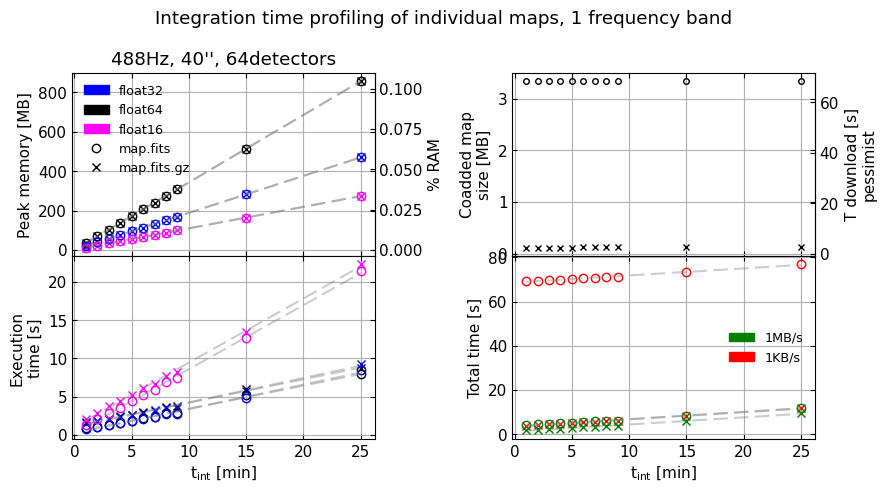

In [20]:
fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True)#,gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle("Integration time profiling of individual maps, 1 frequency band")
axm, axb, axt, axT = axs[0,0], axs[0,1], axs[1,0], axs[1,1], 
key = 'profiling vs tod time'
key2 = "t_int"

for map_compression, marker in zip(('individual.fits.gz', 'individual.fits'), ('x','o')):
    axb.plot(perfs[key][key2], perfs[key]['float64'][map_compression]['output size [MB]'], marker,mfc='none',mec='k', markersize=4)
    print(perfs[key]['float64'][map_compression]['output size [MB]'])

    for precision, color in zip(('float64', 'float32', 'float16'),('k','b','magenta')): 
        axm.plot(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['peak memory [MB]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

        axt.plot(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'],f'{marker}', mfc='none',mec=color,)

        a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision][map_compression]['time [s]'], 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, colort, label in zip((0.048828125, 1), ('r','g'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key]['float32'][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key]['float32'][map_compression]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,f'{marker}', mfc='none',mec=colort, label=label)


        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
patch = mpatches.Patch(color='magenta', label='float16'); patchs.append(patch); 

patch = mlines.Line2D([], [], linestyle='None',marker='o',    markerfacecolor='none',  markeredgecolor='k',  label='map.fits'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='map.fits.gz'); patchs.append(patch)
axm.legend(handles=patchs)

patchs = []
patch = mpatches.Patch(color='g', label='1MB/s'); patchs.append(patch); 
patch = mpatches.Patch(color='r', label='1KB/s'); patchs.append(patch); 
axT.legend(handles=patchs)

def f_to_z(x): return x/ (8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axT.set_ylabel('Total time [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axT.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('Coadded map\nsize [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

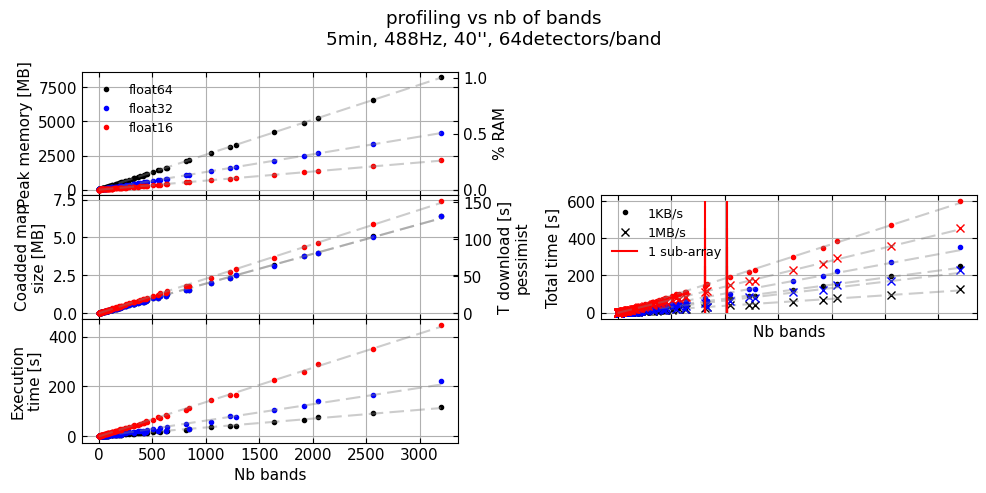

In [18]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[1,1]
axs[2,1].axis('off')
axs[0,1].axis('off')

key = 'profiling vs nb bands'
key2 = "nb dets"

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

for precision, color in zip(('float64', 'float32', 'float16'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
        axT.vlines(16*51, 0, Ttot.max(), color='r')
        axT.vlines(16*64, 0, Ttot.max(), color='r')


patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)



patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='r', linestyle='solid',label='1 sub-array'); patchs.append(patch)

axT.legend(handles=patchs, loc= 'upper left')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("profiling vs nb of bands\n5min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axb.set_ylabel('Coadded map\nsize [MB]')

axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb bands")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

/tmp/ipykernel_11165/897593428.py:37: UserWarning: The following kwargs were not used by contour: 'linestyle'
  CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',
/tmp/ipykernel_11165/897593428.py:85: UserWarning: linewidths is ignored by contourf
  cset1 = ax.contourf(diff, levels=[0,np.abs(diff.max())], norm=norm,linewidths=1.0,linestyle = 'solid', cmap=cmap.resampled(2 - 1), alpha=0.0)
/tmp/ipykernel_11165/897593428.py:85: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cset1 = ax.contourf(diff, levels=[0,np.abs(diff.max())], norm=norm,linewidths=1.0,linestyle = 'solid', cmap=cmap.resampled(2 - 1), alpha=0.0)
/tmp/ipykernel_11165/897593428.py:87: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  paths = cset2.collections[0].get_paths()
/tmp/ipykernel_11165/897593428.py:88: MatplotlibDeprecationWarning: The collections attribute was de

IndexError: list index out of range

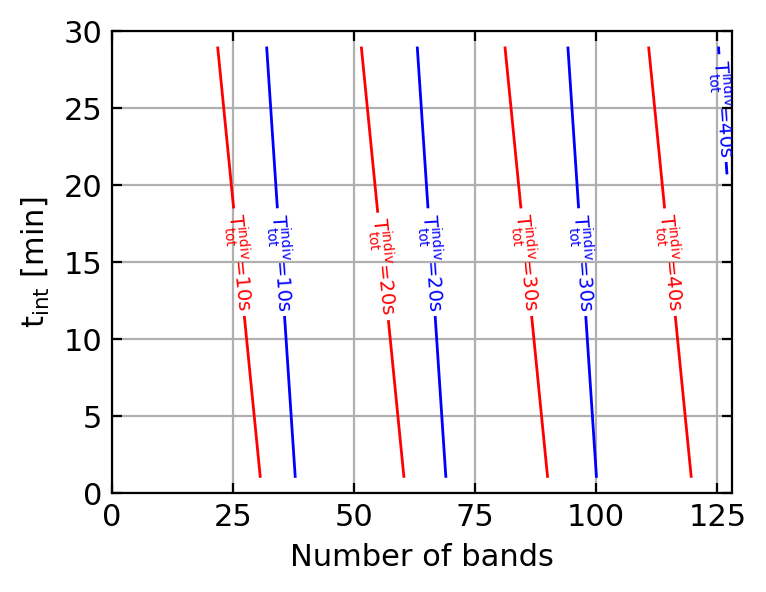

In [26]:
patchs = []
fig, ax = plt.subplots(figsize=(8/2,6/2), dpi=200)
ax.set_xlim(0,64*2)
ax.set_xlabel('Number of bands')
ax.set_ylim(0,30)
ax.set_ylabel('$\\rm t_{int}$ [min]')

#------------------------------
key = 'profiling vs nb bands'
key2 = "nb dets"
precision='float32'
peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_band, b_band = coeffs
#------------------------------

#------------------------------
key = 'profiling vs tod time'
key2 = "t_int"
map_compression = 'individual.fits.gz'
peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
a_tint, b_tint = coeffs
#------------------------------

peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)

'''
im = ax.imshow(peak_mem_tot, cmap='binary')
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.05)
cbar = fig.colorbar(im, cax=cax)
cbar.set_label('Peak Memory [%]')
'''

levels = (0.5,0.6,0.7, 0.8, 0.9, 1)  # 6 contour levels
CS = ax.contour(peak_mem_tot, levels=levels, colors='g', linewidths=1.0,linestyle = ':',
                extent=[x.min(), x.max(), y.min(), y.max()])
ax.clabel(CS, inline=True, fmt=lambda v: f"{v*100:.0f}%RAM", fontsize=7, colors='g')

Ttot_list = []
for telemetry, colort, label in zip((0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):

    #------------------------------
    key = 'profiling vs nb bands'
    key2 = "nb dets"
    precision='float32'

    telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
    Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_band, b_band = coeffs

    key = 'profiling vs tod time'
    key2 = "t_int"
    map_compression = 'individual.fits.gz'
    telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
    Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
    coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    a_tint, b_tint = coeffs

    Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
    Ttot_list.append(Ttot)
    
    '''
    im = ax.imshow(Ttot)
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('$\\rm T_{tot}$ [min]')
    '''
    
    # --- Add constant Ttot lines
    levels = np.asarray((10,20,30,40))/60  # 6 contour levels
    CS = ax.contour(Ttot, levels=levels, colors=colort, linewidths=1.0,
                    extent=[x.min(), x.max(), y.min(), y.max()])
    ax.clabel(CS, inline=True, fmt=lambda v: "$\\rm T^{indiv}_{tot}$="+f"{v*60:.0f}s", fontsize=7, colors=colort)
    patch = mpatches.Patch(color=colort, label=label); patchs.append(patch); 
    #------------------------------
    

diff = np.diff(Ttot_list, axis=0)[0]
norm = cm.colors.Normalize(vmax=1.1, vmin=0)
cmap = cm.PRGn
cset1 = ax.contourf(diff, levels=[0,np.abs(diff.max())], norm=norm,linewidths=1.0,linestyle = 'solid', cmap=cmap.resampled(2 - 1), alpha=0.0)
cset2 = ax.contour(diff, cset1.levels, colors='gray')
paths = cset2.collections[0].get_paths()
paths = cset2.collections[0].get_paths()

coords = cset2.collections[0].get_paths()[0].vertices

# Compute the difference field
cst_time_colors = cm.rainbow(np.linspace(0,1,len(levels)))
        

fig.tight_layout()


In [27]:
Ttot_list[0].max

<function ndarray.max>

TypeError: expected x and y to have same length

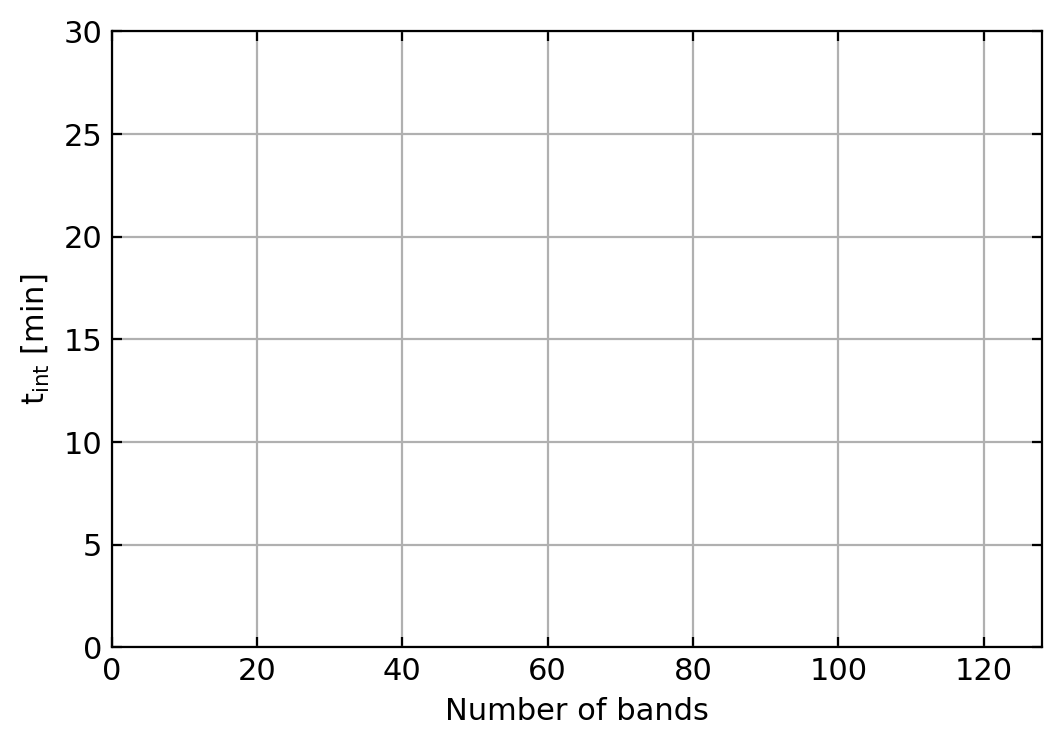

In [12]:
for telemetry, colort, label_telemetry in zip((0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):
    patchs = []
    fig, ax = plt.subplots(figsize=(6,4), dpi=200)
    ax.set_xlim(0,64*2)
    ax.set_xlabel('Number of bands')
    ax.set_ylim(0,30)
    ax.set_ylabel('$\\rm t_{int}$ [min]')

    linear_params_list = np.zeros((2,4))
    Ttot_list = []
    levels = np.asarray((45,60,90))/60  
    dict_coords = {}

        
    for i, (dictfile, map_compression, color, ls, label) in enumerate(zip(('fits_and_hdf5/namap_perf_profiling_individual_maps.p',
                                                                       'fits_and_hdf5/namap_perf_profiling_coadded_maps.p'),
                                                ('individual.fits.gz','coadd.fits'), ('b','orange'), ('solid', '--'), ('individual\nmaps','coadded\nmap'))): 
        perfs = pickle.load( open(dictfile, 'rb'))
        patch = mlines.Line2D([], [], color=color, linestyle='solid',label=label); patchs.append(patch)

        #------------------------------
        key = 'profiling vs nb bands'
        key2 = "nb bands"
        precision='float32'
        peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
        coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
        a_band, b_band = coeffs
        #------------------------------

        #------------------------------
        key = 'profiling vs tod time'
        key2 = "t_int"
        peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
        coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
        a_tint, b_tint = coeffs
        #------------------------------

        peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)
        '''
        im = ax.imshow(peak_mem_tot, cmap='binary')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Peak Memory [%]')
        '''
        
        norm = cm.colors.Normalize(vmax=1.1, vmin=0)
        cmap = cm.binary
        cset1 = ax.contourf(peak_mem_tot, levels=[0.7,1.1], norm=norm,linewidths=1.0,linestyle = ':',
                       cmap=cmap.resampled(2 - 1), alpha=0.2)
        cset2 = ax.contour(peak_mem_tot, cset1.levels, colors='k')
        cset2.set_linestyle(ls)

        #------------------------------
        key = 'profiling vs nb bands'
        key2 = "nb bands"
        precision='float32'

        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
        coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        a_band, b_band = coeffs
        linear_params_list[i,2] = a_tint
        linear_params_list[i,3] = b_tint

        key = 'profiling vs tod time'
        key2 = "t_int"
        telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
        coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        a_tint, b_tint = coeffs

        linear_params_list[i,0] = a_band
        linear_params_list[i,1] = b_band

        Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
        Ttot_list.append(Ttot)
        
        '''
        im = ax.imshow(Ttot)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('$\\rm T_{tot}$ [min]')
        '''
        
        # --- Add constant Ttot lines
        dict_coords[i] = {}
        for level in levels:
            cset2 = ax.contour(Ttot, levels=(level,), colors=color, alpha=0.1)
            coords = cset2.collections[0].get_paths()[0].vertices
            ax.clabel(cset2, inline=True, fmt=lambda v: "$\\rm T_{tot}$="+f"{v*60:.0f}s", fontsize=7, colors=color,)
            dict_coords[i][level] = coords


     
    # Compute the difference field
    cst_time_colors = cm.rainbow(np.linspace(0,1,len(levels)))
    for level, levelcolor in zip(levels, cst_time_colors):
        
        coords1 = dict_coords[0][level]
        coords2 = dict_coords[1][level]
    
        line1 = LineString(coords1)
        line2 = LineString(coords2)
        inter = line1.intersection(line2)
        # Handle either Point or MultiPoint intersections
        inter_pts = [inter] if inter.geom_type == 'Point' else list(inter.geoms)
        p = np.array(inter_pts[0].coords[0])  # take first intersection

        # --- 6️⃣ Find closest vertex to intersection in each contour ---
        idx1 = np.argmin(np.sum((coords1 - p)**2, axis=1))
        idx2 = np.argmin(np.sum((coords2 - p)**2, axis=1))

        import numpy as np

        def line_angle(x, y):
            dx = x[1] - x[0]
            dy = y[1] - y[0]
            return np.abs(np.degrees(np.arctan2(dy, dx)))

        angle_A = line_angle((coords1[idx1,0], coords1[idx1-1,0]), (coords1[idx1,1], coords1[idx1-1,1]))
        angle_B = line_angle((coords2[idx2,0], coords2[idx2-1,0]), (coords2[idx2,1], coords2[idx2-1,1]))

        # --- 7️⃣ Plot partial lines ---
        #if(coords1[0,1] - coords2[0,1] < 0): #inter.is_empty
        if angle_A > angle_B:
            ax.plot(coords1[:idx1,0], coords1[:idx1,1], color=levelcolor, ls='--',)
            ax.plot(coords2[idx2:,0], coords2[idx2:,1], color=levelcolor, ls='--',)
        else: 
            ax.plot(coords1[idx1:,0], coords1[idx1:,1], color=levelcolor, ls='--',)
            ax.plot(coords2[:idx2,0], coords2[:idx2,1], color=levelcolor, ls='--',)
    
    
    diff = np.diff(np.asarray(Ttot_list), axis=0)[0] #indiv-coadde
    norm = cm.colors.Normalize(vmax=1.1, vmin=0)
    cmap = cm.PRGn
    cset1 = ax.contourf(diff, levels=[0,diff.max()], norm=norm,linewidths=1.0,linestyle = 'solid',
                    cmap=cmap.resampled(2 - 1), alpha=0.2)
    cset2 = ax.contour(diff, cset1.levels, colors='k')
    
    '''
    im = ax.imshow(diff,cmap='binary')
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    cbar = fig.colorbar(im, cax=cax)
    cbar.set_label('$\\rm T_{tot}$ [min]')
    '''

    '''
    delta_params = np.diff(linear_params_list, axis=0)
    y_boundary = -(delta_params[0][2] * x + delta_params[0][1] + delta_params[0][3]) / delta_params[0][0]
    ax.plot(x, y_boundary, 'r', lw=2, label='execution = telemetry')
    '''
    fig.tight_layout()

    '''
    patch = mpatches.Patch(color='r',  alpha=0.1,label='$\\rm T^{coadd}_{tot} \geq T^{indiv}_{tot}$'); patchs.append(patch); 
    patch = mpatches.Patch(color='b',  alpha=0.1,label='$\\rm T^{coadd}_{tot} \leq T^{indiv}_{tot}$'); patchs.append(patch); 
    patch = mpatches.Patch(color='k',  alpha=0.8,label='70%RAM\nsafety factor'); patchs.append(patch); 
    patch = mpatches.Patch(color='g', label='%RAM\nin float32'); patchs.append(patch); 

    patch = mlines.Line2D([], [], color='r', linestyle='solid',label='$\\rm T^{coadd}_{tot} = T^{indiv}_{tot}$'); patchs.append(patch)


    ax.legend(handles=patchs, bbox_to_anchor = (1.5,0.8))
    '''
        


In [12]:
file_perfs = 'fits_and_hdf5/namap_perf_profiling_tods.p'
perfs = pickle.load( open(file_perfs, 'rb'))

KeyError: 'peak memory [MB]'

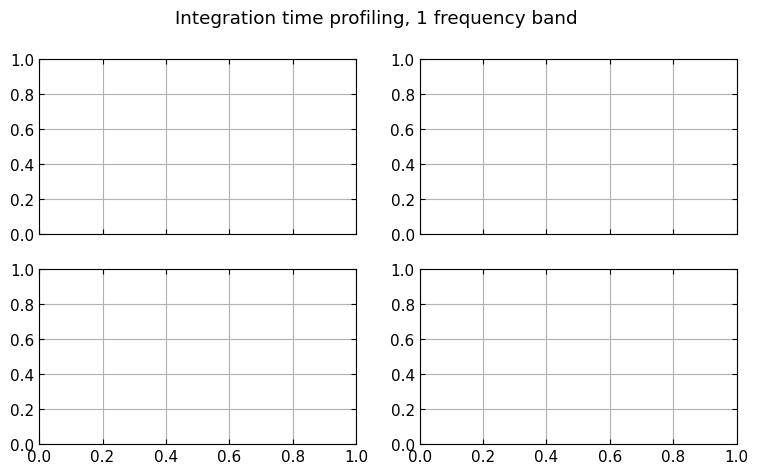

In [13]:
fig, axs = plt.subplots(2,2,figsize=(9,5), sharex=True)#,gridspec_kw={'height_ratios': [2, 2, 1]})
fig.suptitle("Integration time profiling, 1 frequency band")
axm, axb, axt, axT = axs[0,0], axs[0,1], axs[1,0], axs[1,1], 
key = 'profiling vs tod time'
key2 = "t_int"

marker='o'


for precision, color in zip(('float64','float32', 'int8'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'{marker}', mfc='none',mec=color,)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'],f'{marker}', mfc='none',mec=color,)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], marker,mfc='none',mec=color, markersize=4)


for telemetry, colort, label in zip((0.048828125, 1), ('r','g'), ('1KB/s', '1MB/s')):
    telemetry_time = np.asarray(perfs[key]['float32']['output size [MB]']) / telemetry
    Ttot =  np.asarray(perfs[key]['float32']['time [s]'])+telemetry_time
    axT.plot(perfs[key][key2],Ttot,f'{marker}', mfc='none',mec=colort, label=label)


    a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)

patchs = []
patch = mpatches.Patch(color='g', label='1MB/s'); patchs.append(patch); 
patch = mpatches.Patch(color='r', label='1KB/s'); patchs.append(patch); 
axT.legend(handles=patchs)


def f_to_z(x): return x/ (8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

ymin, ymax = axm.get_ylim()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axT.set_ylabel('Total time [s]')
axm.set_title("488Hz, 40'', 64detectors")
axt.set_xlabel("$\\rm t_{int}$ [min]")
axT.set_xlabel("$\\rm t_{int}$ [min]")
axb.set_ylabel('hdf5 size [MB]')

fig.tight_layout()
fig.subplots_adjust(hspace=0)

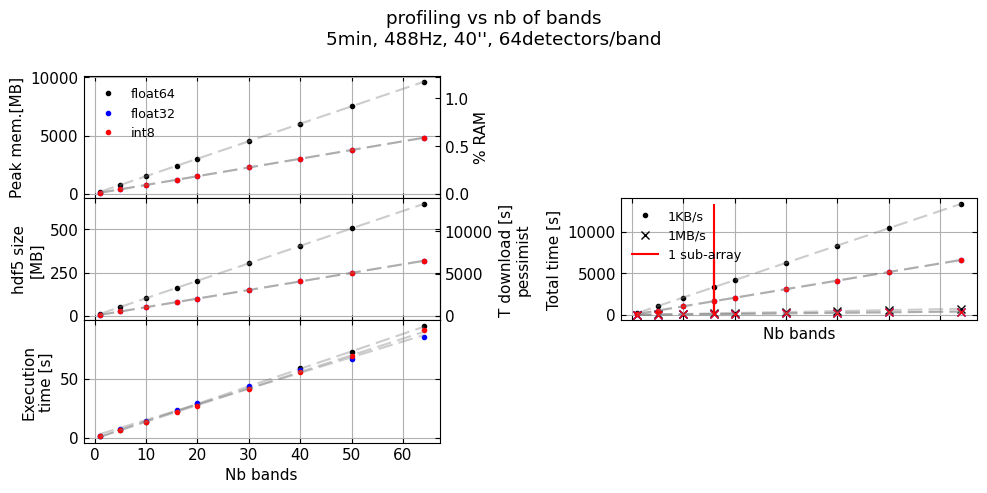

In [ ]:
fig, axs = plt.subplots(3,2,figsize=(10,5), sharex=True,)
axm, axb, axt, axT = axs[0,0], axs[1,0], axs[2,0],axs[1,1]
axs[2,1].axis('off')
axs[0,1].axis('off')

key = 'profiling vs nb bands'
key2 = "nb bands"

def f_to_z(x): return x/(8 *1024)
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

def f_to_z(x): return x/0.048828125
secax = axb.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'T download [s]\npessimist')

for precision, color in zip(('float64','float32', 'int8'),('k','b','r')): 
    axm.plot(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], f'.{color}', label= precision)
    axb.plot(perfs[key][key2], perfs[key][precision]['output size [MB]'], f'.{color}')
    axt.plot(perfs[key][key2], perfs[key][precision]['time [s]'], f'.{color}')

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['peak memory [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axm.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['output size [MB]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axb.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    a_coeffs = np.polyfit(perfs[key][key2], perfs[key][precision]['time [s]'], 1)
    p_lin = np.poly1d(a_coeffs)
    x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
    y_lin = p_lin(x_fit)
    axt.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)

    for telemetry, marker, label in zip((0.048828125, 1), ('.','x'), ('1KB/s', '1MB/s')):
        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision]['time [s]'])+telemetry_time
        axT.plot(perfs[key][key2],Ttot,marker, c=color, label=label)

        a_coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        p_lin = np.poly1d(a_coeffs)
        x_fit = np.linspace(min(perfs[key][key2]), max(perfs[key][key2]), 200)
        y_lin = p_lin(x_fit)
        axT.plot(x_fit, y_lin, color='gray', linestyle='--', alpha=0.4)
        axT.vlines(16, 0, Ttot.max(), color='r')


patchs = []
patch = mpatches.Patch(color='b', label='float32'); patchs.append(patch); 
patch = mpatches.Patch(color='k', label='float64'); patchs.append(patch); 
axm.legend(handles=patchs)

patchs = []
patch = mlines.Line2D([], [], linestyle='None',marker='.',    color='k', label='1KB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='k', linestyle='None',marker='x',  label='1MB/s'); patchs.append(patch)
patch = mlines.Line2D([], [], color='r', linestyle='solid',label='1 sub-array'); patchs.append(patch)

axT.legend(handles=patchs, loc= 'upper left')

ymin, ymax = axm.get_ylim()
axm.legend()
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak mem.[MB]')
axt.set_ylabel('Execution\ntime [s]')
fig.suptitle("profiling vs nb of bands\n5min, 488Hz, 40'', 64detectors/band")
axt.set_xlabel("Nb bands")
axb.set_ylabel('hdf5 size\n[MB]')

axT.set_ylabel('Total time [s]')
axT.set_xlabel("Nb bands")

fig.tight_layout()
fig.subplots_adjust(hspace=0)

/tmp/ipykernel_55097/3138933540.py:53: UserWarning: linewidths is ignored by contourf
  cset1 = ax.contourf(peak_mem_tot, levels=[0.7,1.1], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
/tmp/ipykernel_55097/3138933540.py:53: UserWarning: The following kwargs were not used by contour: 'linestyle'
  cset1 = ax.contourf(peak_mem_tot, levels=[0.7,1.1], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
/tmp/ipykernel_55097/3138933540.py:91: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  if len(cset2.collections) == 0:
/tmp/ipykernel_55097/3138933540.py:93: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed two minor releases later.
  paths = cset2.collections[0].get_paths()
/tmp/ipykernel_55097/3138933540.py:98: MatplotlibDeprecationWarning: The collections attribute was deprecated 

level= 0.5
level= 0.75
level= 1
level= 1.5
level= 0.75
level= 1
level= 1.5
level= 2
level= 0.75
level= 1
level= 1.5
level= 2


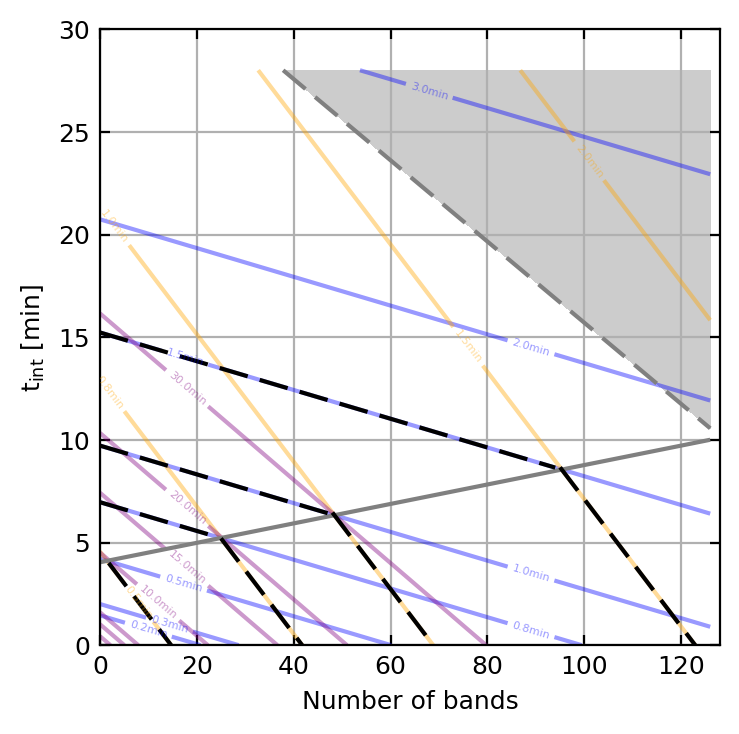

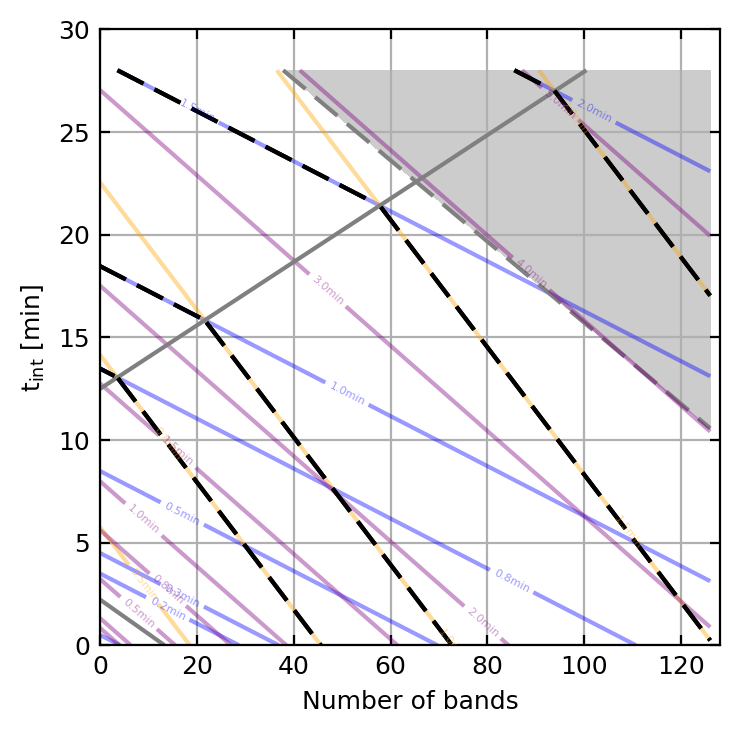

In [21]:
matplotlib.rcParams.update({'font.size': 9})

for telemetry, colort, label_telemetry in zip( (0.048828125, 1), ('r','b'), ('1KB/s','1MB/s')):

    patchs = []
    fig, ax = plt.subplots(figsize=(4,4), dpi=200)
    ax.set_xlim(0,64*2)
    ax.set_xlabel('Number of bands')
    ax.set_ylim(0,30)
    ax.set_ylabel('$\\rm t_{int}$ [min]')
    Ttot_list = []

    for i, (dictfile, map_compression, color, ls, label) in enumerate(zip(('fits_and_hdf5/namap_perf_profiling_individual_maps.p',
                                                                           'fits_and_hdf5/namap_perf_profiling_coadded_maps.p',
                                                                           'fits_and_hdf5/namap_perf_profiling_tods.p'),
                                                                            ('individual.fits.gz','coadd.fits','tods.hdf5'), 
                                                                            ('b','orange', 'purple'), 
                                                                            ('solid', '--', ':'), 
                                                                            ('individual\nmaps','coadded\nmap','tods'))): 
        


        perfs = pickle.load( open(dictfile, 'rb'))
        patch = mlines.Line2D([], [], color=color, linestyle='solid',label=label); patchs.append(patch)

        #------------------------------
        key = 'profiling vs nb bands'
        key2 = "nb bands"
        precision='float32'
        peak_mem = np.asarray(perfs[key][precision]['peak memory [MB]']) 
        coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
        a_band, b_band = coeffs
        #------------------------------

        #------------------------------
        key = 'profiling vs tod time'
        key2 = "t_int"
        peak_mem = np.asarray(perfs[key][precision][map_compression]['peak memory [MB]']) 
        coeffs = np.polyfit(perfs[key][key2], peak_mem, 1)
        a_tint, b_tint = coeffs
        #------------------------------

        peak_mem_tot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band)/(8*1024)
        '''
        im = ax.imshow(peak_mem_tot, cmap='binary')
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('Peak Memory [%]')
        '''
        norm = cm.colors.Normalize(vmax=1.1, vmin=0)
        cmap = cm.binary
        cset1 = ax.contourf(peak_mem_tot, levels=[0.7,1.1], norm=norm,linewidths=1.0,linestyle = ':',cmap=cmap.resampled(2 - 1), alpha=0.2)
        cset2 = ax.contour(peak_mem_tot, cset1.levels, colors='gray')
        cset2.set_linestyle(ls)

        
        #------------------------------
        key = 'profiling vs nb bands'
        key2 = "nb bands"
        precision='float32'

        telemetry_time = np.asarray(perfs[key][precision]['output size [MB]']) / telemetry
        Ttot =           np.asarray(perfs[key][precision]['time [s]']) +telemetry_time
        coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        a_band, b_band = coeffs

        key = 'profiling vs tod time'
        key2 = "t_int"
        telemetry_time = np.asarray(perfs[key][precision][map_compression]['output size [MB]']) / telemetry
        Ttot =  np.asarray(perfs[key][precision][map_compression]['time [s]'])+telemetry_time
        coeffs = np.polyfit(perfs[key][key2], Ttot, 1)
        a_tint, b_tint = coeffs

        Ttot = (a_tint*T_grid+a_band*N_grid+b_tint+b_band) / 60
        Ttot_list.append(Ttot)
        
        '''
        im = ax.imshow(Ttot)
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.05)
        cbar = fig.colorbar(im, cax=cax)
        cbar.set_label('$\\rm T_{tot}$ [min]')
        '''
        levels = (0.1,0.3,0.25,0.5,45/60,1,1.5,2,3,4,5,10,15,20,30)
        # --- Add constant Ttot lines
        dict_coords[i] = {}
        for level in levels:
            cset2 = ax.contour(Ttot, levels=(level,), colors=color, alpha=0.4)
            # Skip this level if no contour created
            if len(cset2.collections) == 0:
                continue
            paths = cset2.collections[0].get_paths()

            if len(paths) == 0:
                continue

            coords = cset2.collections[0].get_paths()[0].vertices
            ax.clabel(cset2, inline=True, fmt=lambda v:f"{v:.1f}min", fontsize=4, colors=color,)
            dict_coords[i][level] = coords


    diff = np.diff(Ttot_list, axis=0)
    norm = cm.colors.Normalize(vmax=1.1, vmin=0)
    cmap = cm.PRGn

    for j in range(len(diff)):

        cset1 = ax.contourf(diff[j], levels=[0,diff.max()], norm=norm,linewidths=1.0,linestyle = 'solid', cmap=cmap.resampled(2 - 1), alpha=0.0)
        cset2 = ax.contour(diff[j], cset1.levels, colors='gray')
        paths = cset2.collections[0].get_paths()

        if len(cset2.collections) == 0: continue
        paths = cset2.collections[0].get_paths()
        if len(paths) == 0: continue

        coords = cset2.collections[0].get_paths()[0].vertices

        # Compute the difference field
        cst_time_colors = cm.rainbow(np.linspace(0,1,len(levels)))
            
        for level, levelcolor in zip(levels, cst_time_colors):
            if((level in dict_coords[0]) and (level in dict_coords[1])): 
            
                coords1 = dict_coords[0][level]
                coords2 = dict_coords[1][level]

                if((len(coords1) >0) and (len(coords2)>0 )): 
            
                    line1 = LineString(coords1)
                    line2 = LineString(coords2)
                    
                    inter = line1.intersection(line2)
                    if inter.geom_type != "Point": continue

                    # Otherwise we can safely use it
                    p = np.array(inter.coords[0])
                    
                    # --- 6️⃣ Find closest vertex to intersection in each contour ---
                    idx1 = np.argmin(np.sum((coords1 - p)**2, axis=1))
                    idx2 = np.argmin(np.sum((coords2 - p)**2, axis=1))


                    def line_angle(x, y):
                        dx = x[1] - x[0]
                        dy = y[1] - y[0]
                        return np.abs(np.degrees(np.arctan2(dy, dx)))

                    angle_A = line_angle((coords1[idx1,0], coords1[idx1-1,0]), (coords1[idx1,1], coords1[idx1-1,1]))
                    angle_B = line_angle((coords2[idx2,0], coords2[idx2-1,0]), (coords2[idx2,1], coords2[idx2-1,1]))

                    # --- 7️⃣ Plot partial lines ---
                    #if(coords1[0,1] - coords2[0,1] < 0): #inter.is_empty
                    if angle_A > angle_B:
                        ax.plot(coords1[:idx1,0], coords1[:idx1,1], color='k', ls='--',)
                        ax.plot(coords2[idx2:,0], coords2[idx2:,1], color='k', ls='--',)
                    else: 
                        ax.plot(coords1[idx1:,0], coords1[idx1:,1], color='k', ls='--',)
                        ax.plot(coords2[:idx2,0], coords2[:idx2,1], color='k', ls='--',)
                
                    print('level=',level)
                    

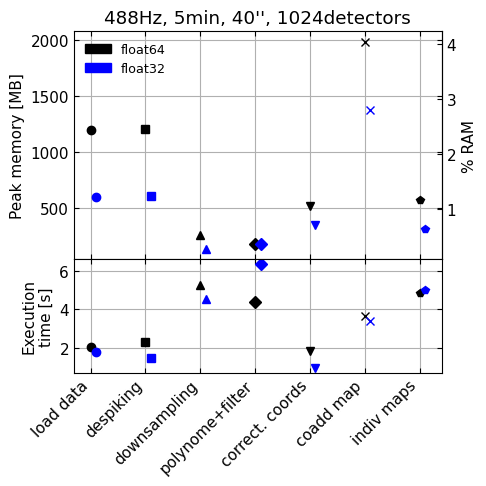

In [ ]:
dictfile = 'fits_and_hdf5/namap_perf_profiling_fcts.p'

perfs = pickle.load( open(dictfile, 'rb'))

fig, (axm, axt) = plt.subplots(2,figsize=(5,5), sharex=True,gridspec_kw={'height_ratios': [2,  1]})
key = 'profiling fcts'
fcts_list = ('loaddata','despiking','zoom_sync',  'polynome_fft_filter','correct_coords','map_making_coadd', 'map_making_indiv')
fcts_list_name = ('load data','despiking','downsampling', 'polynome+filter','correct. coords','coadd map','indiv maps') #'downsizing', 'signal.resample','sigmal.resample_poly',

patchs = []
for ip, (precision, color) in enumerate(zip(('float64', 'float32'),('k','b','r'))): 
    patch = mpatches.Patch(color=color, label= precision); patchs.append(patch); 

    for fi, (fct, m) in enumerate(zip(fcts_list,('o', 's', '^', 'D', 'v', 'x', 'p', 'H','*'))):

        #if(color=='b'): patch = mlines.Line2D([], [], color='k', linestyle='None',marker=m,  label=fct); patchs.append(patch)
        axm.plot((fi+1+0.1*ip), perfs[key][precision][fct]['peak memory [MB]'], color=f'{color}', marker = m)
        axt.plot((fi+1+0.1*ip), perfs[key][precision][fct]['time [s]'], color=f'{color}', marker = m)

def f_to_z(x): return x/49152*100
secax = axm.secondary_yaxis("right", functions=(f_to_z,f_to_z))
secax.set_ylabel(f'% RAM')

ymin, ymax = axm.get_ylim()
axm.legend(handles=patchs)
#axm.set_yticks(np.arange(int(0), int(ymax)+10, 150))
axm.set_ylabel('Peak memory [MB]')
axt.set_ylabel('Execution\ntime [s]')
axm.set_title("488Hz, 5min, 40'', 1024detectors")

axt.set_xticks(range(1, len(fcts_list)+1))
axt.set_xticklabels(fcts_list_name, rotation=45, ha='right')


fig.tight_layout()
fig.subplots_adjust(hspace=0)